# 01 — Data Exploration

Load a single MIT-BIH Arrhythmia Database record and its expert annotations, and inspect the metadata every later stage depends on. No filtering or ML yet.

## 1-2. Load the record and its annotations

`wfdb.rdrecord` loads the physical signal. `wfdb.rdann` loads a *separate* file of cardiologist-reviewed beat annotations — ground truth we did not compute ourselves.

In [2]:
import wfdb
import collections

RECORD_NAME = "100"

record = wfdb.rdrecord(RECORD_NAME, pn_dir="mitdb")
annotation = wfdb.rdann(RECORD_NAME, "atr", pn_dir="mitdb")

## 3-5. Sampling frequency, signal length, number of channels

- `fs`: samples recorded per second. Converts sample indices to real time everywhere downstream.
- `sig_len`: total number of samples; `sig_len / fs` gives the recording duration in seconds.
- `n_sig`: number of simultaneously recorded ECG leads (electrode placements).

In [3]:
print("Sampling frequency (Hz):", record.fs)
print("Signal length (samples):", record.sig_len)
print("Number of channels:", record.n_sig)
print("Channel names:", record.sig_name)
print("Units:", record.units)
print("Duration (seconds):", record.sig_len / record.fs)
print("Duration (minutes):", record.sig_len / record.fs / 60)

Sampling frequency (Hz): 360
Signal length (samples): 650000
Number of channels: 2
Channel names: ['MLII', 'V5']
Units: ['mV', 'mV']
Duration (seconds): 1805.5555555555557
Duration (minutes): 30.092592592592595


## 6. Extract the ECG signal

`record.p_signal` is a NumPy array of shape `(sig_len, n_sig)` in physical units (mV), not raw ADC integers. We'll work with a single lead — MLII when available, since it's the most commonly used lead for beat detection — and keep the other channel unused for now.

In [6]:
print("p_signal shape:", record.p_signal.shape)

lead_index = record.sig_name.index("MLII") if "MLII" in record.sig_name else 0
ecg_signal = record.p_signal[:, lead_index]

print(f"Using lead '{record.sig_name[lead_index]}' (index {lead_index})")
print("ecg_signal shape:", ecg_signal.shape)
print("First 10 samples (mV):", ecg_signal[:10])

p_signal shape: (650000, 2)
Using lead 'MLII' (index 0)
ecg_signal shape: (650000,)
First 10 samples (mV): [-0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.12  -0.135]


## 7. Inspect annotation symbols and locations

- `annotation.sample`: sample index of each annotated event.
- `annotation.symbol`: a one-character code for what was annotated there (e.g. `N` = normal beat, `V` = PVC, `A` = atrial premature beat). Not every symbol marks a beat — some mark rhythm or signal-quality notes; we'll handle that distinction carefully at the labeling stage. For now we're just looking at what's present in this record.

In [5]:
print("Number of annotations:", len(annotation.sample))
print("First 10 annotation sample indices:", annotation.sample[:10])
print("First 10 annotation symbols:", annotation.symbol[:10])
print("Symbol counts:", collections.Counter(annotation.symbol))

Number of annotations: 2274
First 10 annotation sample indices: [  18   77  370  662  946 1231 1515 1809 2044 2402]
First 10 annotation symbols: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']
Symbol counts: Counter({'N': 2239, 'A': 33, '+': 1, 'V': 1})


## Basic ECG morphology

Before looking at plots, a quick vocabulary. One heartbeat on ECG has three
named waves, in this order:

- **P wave**: a small, gentle bump. The atria (the heart's upper chambers)
  contracting to push blood into the ventricles.
- **QRS complex**: a sharp, tall spike — by far the largest deflection in
  the signal. The ventricles (the main pumping chambers) contracting. This
  is the electrical event that actually drives a pulse.
- **R peak**: the highest point *within* the QRS complex. Because it's the
  single largest, sharpest feature in the whole signal, it's the easiest
  and most reliable point to detect algorithmically — which is why R-peak
  detection (not P or T wave detection) is the anchor for the rest of this
  pipeline.
- **T wave**: a broader, gentler bump after the QRS. The ventricles
  electrically "resetting" (repolarizing) before the next beat.

So one beat reads: small bump (P) -> sharp spike (QRS, peak = R) -> broad
bump (T) -> flat-ish gap -> repeat.

## Visualizing the raw signal (before any processing)

Three views, each answering a different question:

1. **A longer section (10s)** — what does the overall rhythm look like?
   Are beats evenly spaced? Is there slow drift in the baseline?
2. **A short zoom (3s)** — can I actually see the P-QRS-T shape of
   individual beats?
3. **Annotations overlaid** — do the expert-marked beat locations line up
   with what visually looks like the R-peak?

No filtering yet — this is what the sensor actually recorded.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

fs = record.fs
ann_samples = annotation.sample
ann_symbols = np.array(annotation.symbol)
time = np.arange(len(ecg_signal)) / fs
ann_time = ann_samples / fs

### 1. Longer section (10 seconds)

**Look for:** are the spikes (heartbeats) roughly evenly spaced (regular
rhythm)? Does the baseline (the resting level between beats) stay flat, or
does it slowly drift up and down over the 10 seconds — that drift is
**baseline wander**, one of the noise sources we'll remove with filtering
in the next stage. Also note the overall amplitude scale (roughly -0.5 to
+1.0 mV here) and whether there's visible high-frequency jitter riding on
top of the clean signal.

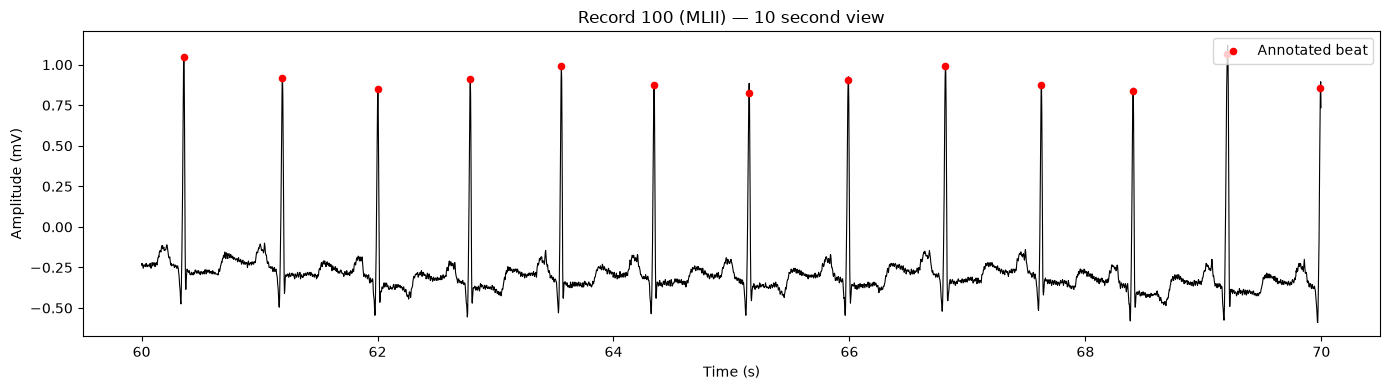

In [8]:
long_start, long_end = 60, 70  # seconds
mask_long = (time >= long_start) & (time < long_end)
ann_mask_long = (ann_time >= long_start) & (ann_time < long_end)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time[mask_long], ecg_signal[mask_long], color="black", linewidth=0.8)
ax.scatter(ann_time[ann_mask_long], ecg_signal[ann_samples[ann_mask_long]],
           color="red", s=20, zorder=3, label="Annotated beat")
ax.set_title(f"Record {RECORD_NAME} (MLII) — 10 second view")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (mV)")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig("../results/figures/01_raw_ecg_long.png", dpi=120)
plt.show()

### 2-3. Zoomed section (3 seconds) with annotations overlaid

**Look for:** the P-QRS-T shape described above, repeated once per beat.
Check that each red dot (the expert-annotated location) lands exactly on
top of the tallest spike (the R peak) — this is a sanity check that the
annotation file is correctly aligned with the signal, which matters a lot
once we start validating our own detector against these labels in a later
stage. Also check the segment between the T wave and the next P wave: it
should be close to flat (the isoelectric baseline) if the signal is clean.

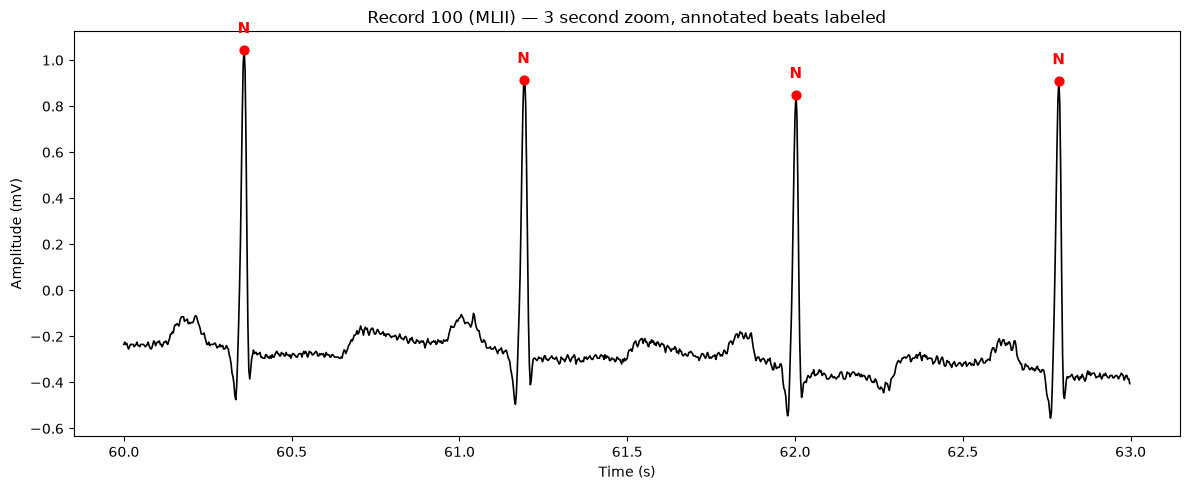

In [9]:
zoom_start, zoom_end = 60, 63  # seconds
mask_zoom = (time >= zoom_start) & (time < zoom_end)
ann_mask_zoom = (ann_time >= zoom_start) & (ann_time < zoom_end)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(time[mask_zoom], ecg_signal[mask_zoom], color="black", linewidth=1.2)
for s, sym in zip(ann_samples[ann_mask_zoom], ann_symbols[ann_mask_zoom]):
    t, y = s / fs, ecg_signal[s]
    ax.scatter(t, y, color="red", s=40, zorder=3)
    ax.annotate(sym, (t, y), textcoords="offset points", xytext=(0, 12),
                ha="center", color="red", fontsize=11, fontweight="bold")
ax.set_title(f"Record {RECORD_NAME} (MLII) — 3 second zoom, annotated beats labeled")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (mV)")
fig.tight_layout()
fig.savefig("../results/figures/02_raw_ecg_zoom_annotated.png", dpi=120)
plt.show()